# Classification de Time Series sur LSST
## CNN Baseline + Mantis Foundation Model

In [ ]:
import numpy as np
import os 
import certifi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import RidgeClassifierCV
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [2]:
# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: mps


## Loading LSST dataset

In [3]:
ds = UCR_UEA_datasets()
X_train_raw, y_train_raw, X_test_raw, y_test_raw = ds.load_dataset('LSST')

print(f'X_train: {X_train_raw.shape}')  # (2459, 36, 6)
print(f'X_test:  {X_test_raw.shape}')   # (2466, 36, 6)
print(f'Classes: {len(set(y_train_raw))}')

X_train: (2459, 36, 6)
X_test:  (2466, 36, 6)
Classes: 14


In [4]:
# Encoder les labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

## CNN Baseline

In [5]:
# Preprocessing CNN : normalisation + gestion NaN + conversion torch
scaler = TimeSeriesScalerMeanVariance()
X_train_cnn = scaler.fit_transform(X_train_raw)
X_test_cnn = scaler.transform(X_test_raw)

X_train_cnn = np.nan_to_num(X_train_cnn, nan=0.0)
X_test_cnn = np.nan_to_num(X_test_cnn, nan=0.0)

X_train_t = torch.tensor(X_train_cnn, dtype=torch.float32)
X_test_t = torch.tensor(X_test_cnn, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

In [6]:
class CNNBaseline(nn.Module):
    def __init__(self, n_channels=6, n_classes=14):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, 36, 6) -> (batch, 6, 36)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

In [8]:
# Entraînement CNN
model_cnn = CNNBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

n_epochs = 100
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model_cnn, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_cnn, test_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')

print(f'\nCNN Baseline - Best Test Acc: {max(history["test_acc"]):.4f}')

Epoch  10/100 | Train Loss: 1.5901 | Train Acc: 0.5083 | Test Loss: 1.5200 | Test Acc: 0.5483
Epoch  20/100 | Train Loss: 1.3764 | Train Acc: 0.5612 | Test Loss: 1.3333 | Test Acc: 0.5811
Epoch  30/100 | Train Loss: 1.2505 | Train Acc: 0.5966 | Test Loss: 1.2505 | Test Acc: 0.6030
Epoch  40/100 | Train Loss: 1.1643 | Train Acc: 0.6214 | Test Loss: 1.2073 | Test Acc: 0.6107
Epoch  50/100 | Train Loss: 1.1014 | Train Acc: 0.6458 | Test Loss: 1.1682 | Test Acc: 0.6330
Epoch  60/100 | Train Loss: 1.0142 | Train Acc: 0.6645 | Test Loss: 1.1541 | Test Acc: 0.6375
Epoch  70/100 | Train Loss: 0.9523 | Train Acc: 0.6865 | Test Loss: 1.1506 | Test Acc: 0.6383
Epoch  80/100 | Train Loss: 0.9169 | Train Acc: 0.7007 | Test Loss: 1.1561 | Test Acc: 0.6403
Epoch  90/100 | Train Loss: 0.8575 | Train Acc: 0.7186 | Test Loss: 1.1620 | Test Acc: 0.6375
Epoch 100/100 | Train Loss: 0.8215 | Train Acc: 0.7239 | Test Loss: 1.1811 | Test Acc: 0.6245

CNN Baseline - Best Test Acc: 0.6415


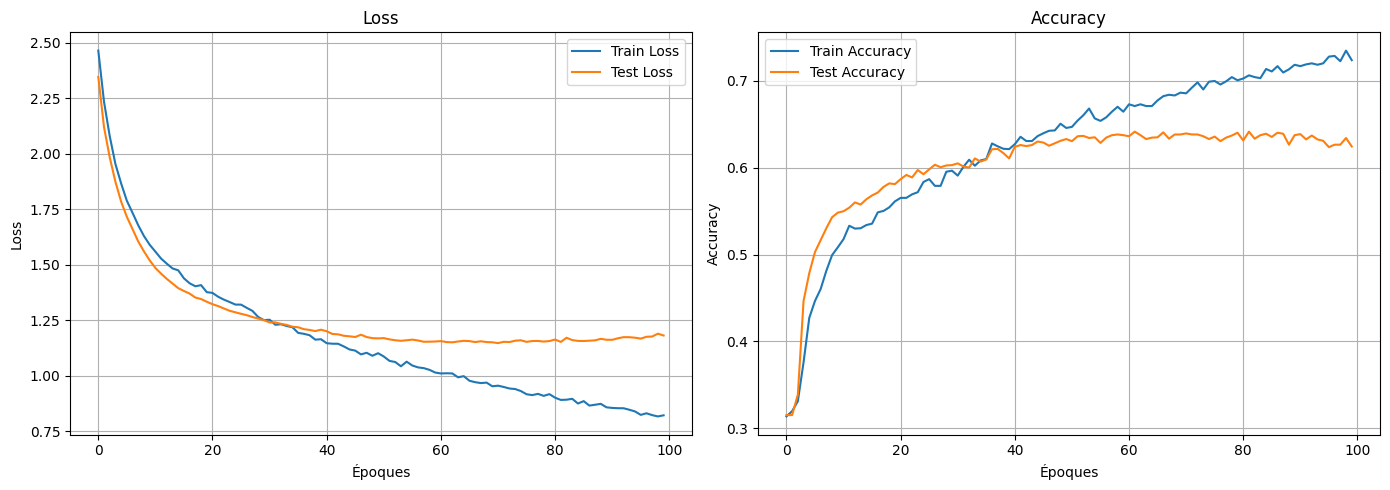

In [9]:
# Courbes d'entraînement CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set(title='Loss', xlabel='Époques', ylabel='Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['test_acc'], label='Test Accuracy')
ax2.set(title='Accuracy', xlabel='Époques', ylabel='Accuracy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Mantis Foundation Model

In [10]:
from mantis.architecture import Mantis8M
from mantis.trainer import MantisTrainer
from mantis.adapters import LinearChannelCombiner

# Preprocessing Mantis : pas de normalisation (Mantis le fait en interne), juste NaN -> 0
X_train_m = np.nan_to_num(X_train_raw, nan=0.0).transpose(0, 2, 1)  # (2459, 6, 36)
X_test_m = np.nan_to_num(X_test_raw, nan=0.0).transpose(0, 2, 1)    # (2466, 6, 36)

# Resize à 128 (doit être multiple de 32)
def resize(X, size=128):
    X_tensor = torch.tensor(X, dtype=torch.float)
    return F.interpolate(X_tensor, size=size, mode='linear', align_corners=False).numpy()

X_train_m = resize(X_train_m)
X_test_m = resize(X_test_m)
print(f'Format Mantis: {X_train_m.shape}')

Format Mantis: (2459, 6, 128)


### Zero-shot ("Frozen backbone + linear classifier")

In [11]:
network_zs = Mantis8M(device=str(device))
network_zs = network_zs.from_pretrained('paris-noah/Mantis-8M')

model_zs = MantisTrainer(device=str(device), network=network_zs)
Z_train = model_zs.transform(X_train_m)
Z_test = model_zs.transform(X_test_m)

clf = RidgeClassifierCV()
clf.fit(Z_train, y_train)
y_pred_zs = clf.predict(Z_test)

zs_acc = accuracy_score(y_test, y_pred_zs)
print(f'Mantis Zero-shot Accuracy: {zs_acc:.4f}')

Mantis Zero-shot Accuracy: 0.5848


### Fine-tuning (full)

In [12]:
network_ft = Mantis8M(device=str(device))
network_ft = network_ft.from_pretrained('paris-noah/Mantis-8M')

model_ft = MantisTrainer(device=str(device), network=network_ft)

model_ft.fit(
    X_train_m, y_train,
    num_epochs=20,
    fine_tuning_type='full'
)

y_pred_ft = model_ft.predict(X_test_m)
ft_acc = accuracy_score(y_test, y_pred_ft)
print(f'Mantis Fine-tuned Accuracy: {ft_acc:.4f}')

Epoch 19: Train Loss 0.5069: 100%|██████████| 20/20 [14:27<00:00, 43.36s/it]


Mantis Fine-tuned Accuracy: 0.7056


In [13]:
print('--- Classification Report (Mantis Fine-tuned) ---')
print(classification_report(y_test, y_pred_ft, target_names=le.classes_))

--- Classification Report (Mantis Fine-tuned) ---
              precision    recall  f1-score   support

          15       0.66      0.56      0.60       124
          16       0.97      0.95      0.96       270
          42       0.51      0.60      0.55       382
          52       0.00      0.00      0.00        63
          53       1.00      0.71      0.83         7
           6       0.64      0.40      0.49        35
          62       0.38      0.25      0.30       153
          64       0.00      0.00      0.00        24
          65       0.79      0.94      0.86       313
          67       0.22      0.03      0.05        68
          88       0.96      0.98      0.97       121
          90       0.68      0.81      0.74       777
          92       0.91      0.94      0.92        77
          95       0.64      0.27      0.38        52

    accuracy                           0.71      2466
   macro avg       0.60      0.53      0.55      2466
weighted avg       0.67      0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


## Récapitulatif

In [14]:
cnn_acc = max(history['test_acc'])

print(f'CNN Baseline:         {cnn_acc:.4f}')
print(f'Mantis Zero-shot:     {zs_acc:.4f}')
print(f'Mantis Fine-tuned:    {ft_acc:.4f}')

CNN Baseline:         0.6415
Mantis Zero-shot:     0.5848
Mantis Fine-tuned:    0.7056


### 3 seed average (mantis fine tuned full)

In [16]:
seeds = [42, 123, 456]
results_mantis = {'accuracy': [], 'f1_macro': [], 'f1_weighted': []}

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    network_ft = Mantis8M(device=str(device))
    network_ft = network_ft.from_pretrained('paris-noah/Mantis-8M')
    model_ft = MantisTrainer(device=str(device), network=network_ft)
    
    model_ft.fit(
        X_train_m, y_train,
        num_epochs=20,
        fine_tuning_type='full'
    )
    
    y_pred = model_ft.predict(X_test_m)
    
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    
    results_mantis['accuracy'].append(acc)
    results_mantis['f1_macro'].append(f1_m)
    results_mantis['f1_weighted'].append(f1_w)
    
    print(f'Seed {seed}: Acc={acc:.4f} | F1 macro={f1_m:.4f} | F1 weighted={f1_w:.4f}')

print('\n--- Mantis Fine-tuned (moyenne ± std sur 3 seeds) ---')
for metric, values in results_mantis.items():
    print(f'{metric:15s}: {np.mean(values):.4f} ± {np.std(values):.4f}')

Epoch 19: Train Loss 0.4930: 100%|██████████| 20/20 [13:22<00:00, 40.12s/it]


Seed 42: Acc=0.6942 | F1 macro=0.5362 | F1 weighted=0.6679


Epoch 19: Train Loss 0.5137: 100%|██████████| 20/20 [15:32<00:00, 46.61s/it]


Seed 123: Acc=0.7028 | F1 macro=0.5275 | F1 weighted=0.6675


Epoch 19: Train Loss 0.5282: 100%|██████████| 20/20 [18:35<00:00, 55.76s/it]


Seed 456: Acc=0.6979 | F1 macro=0.5226 | F1 weighted=0.6659

--- Mantis Fine-tuned (moyenne ± std sur 3 seeds) ---
accuracy       : 0.6983 ± 0.0035
f1_macro       : 0.5288 ± 0.0056
f1_weighted    : 0.6671 ± 0.0009


On bat le baseline mais le f1 score reste moyen (on prédit surtout les classes dominantes dans le dataset)